# Predicting Taxi Trip Duration and Congestion Pricing Exposure in New York City

Final project report (single notebook). **Run all cells** with the notebook directory set to `final/` (typical default when you open this file), or adjust `REPO_ROOT` in the setup cell.


### Team

| Name | GitHub ID |
|------|-----------|
| Abhishek Mohan Hundalekar | hundalekar  |
| Moses Kamya | mkamya20 |
| Tarun Singh | tsingh15syr |
| Morgan Cook | mcook12e |


### Introduction

NYC yellow-taxi trips generate enormous TLC records every day. **Drivers and dispatchers** need reasonable **time expectations** so they can plan shifts, accept rides, and avoid chronic lateness. **Fleet operators and policy-facing agencies** need transparent ways to understand **when congestion-style surcharges apply** and how often models would flag trips—without treating a single accuracy number as the whole story. The underlying need is practical: **turn messy trip logs into reliable, interpretable signals** that support planning and accountability, not just a leaderboard score.

This project builds an **incremental but real** answer to that need. We clean and engineer features from TLC-style yellow-taxi data, then treat the problem as two linked tasks: **regression** for **trip duration in minutes**, and **binary classification** for **whether a trip carries a congestion-related fee flag** (as defined from the engineered dataset). The solution is an end-to-end **notebook pipeline**—from parquet through baselines to diagnostics with **stronger ensemble models** explored in the `work/` notebooks for teams that want higher accuracy.

Stakeholders get **interpretable duration error in minutes** and **classification metrics beyond accuracy** (precision, recall, F1, ROC-style discrimination) so fee exposure is discussed honestly on **imbalanced** data. That is best understood as a **foundation step**: the same pipeline and metrics extend naturally toward **scheduled retraining, calibration, monitoring, and deployment** once data refresh and governance requirements are in scope.

### Literature Review

**Stakeholder need:** Urban for-hire regulations and congestion pricing change the economic landscape for drivers. TLC trip-level microdata are the standard empirical basis for studying taxi markets (supply, demand, and fare components). Predicting duration and fee incidence supports **route/dispatch intuition** and **policy evaluation** when linked to transparent features and validation.

**Prior work and method choices:** Trip duration prediction from TLC logs commonly uses regression with temporal and geographic descriptors; strong correlations among distance, fare, and duration are well documented, motivating both simple baselines and models that handle non-linearity. **Linear regression** and **logistic regression** provide calibrated, explainable references and expose multicollinearity/leakage issues early. **Random forests** and **gradient boosted trees** are standard when interactions and thresholds matter (e.g., rush hour, borough pairs, distance buckets), they align with our goal of improving RMSE/MAE for duration and discrimination for congestion exposure beyond linear separators.

We chose **January 2025** data specifically because the TLC schema includes **`cbd_congestion_fee`**, enabling a fee-exposure label aligned with the recent CBD program rather than proxy outcomes from earlier years.


### Data and Methods

#### Data

**Source.** [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — Yellow Taxi, **January 2025** (Parquet), plus the TLC **Taxi Zone Lookup** for borough/zone context.

**Quality and scope.** Records come from mandatory reporting for licensed yellow taxis; the TLC publishes dictionaries and consistent schemas. We restricted trips to **January 5–31, 2025** so all trips fall in the post–congestion-pricing window for this dataset release. After cleaning (see `work/02_data_cleaning/02_data_cleaning.ipynb`), the engineered analytical file contains on the order of **~2.45M trips** (from ~3.47M raw rows); the engineered feature table has **45 columns** (`data/processed/taxi_engineered.parquet`).

**Targets.** Regression: `trip_duration_min` (minutes). Classification: `has_congestion_fee` (1 if `cbd_congestion_fee` > 0).

**Class balance.** Roughly **~74%** of cleaned trips have a congestion fee; the negative class is minority — report ROC-AUC, precision/recall/F1, and confusion matrices in addition to accuracy.




In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

assert DATA_PATH.exists(), (
    f"Missing {DATA_PATH}. Run work/02_data_cleaning and feature notebooks first, "
    "or download/process TLC data per project docs."
)

df = pd.read_parquet(DATA_PATH)
plot_df = df.copy()
print("Rows loaded (full cleaned dataset for Data figures):", len(plot_df))


Rows loaded (full cleaned dataset for Data figures): 2451103


**Figure 1.** Distribution of trip duration (minutes) and class balance for congestion fee (full cleaned dataset).

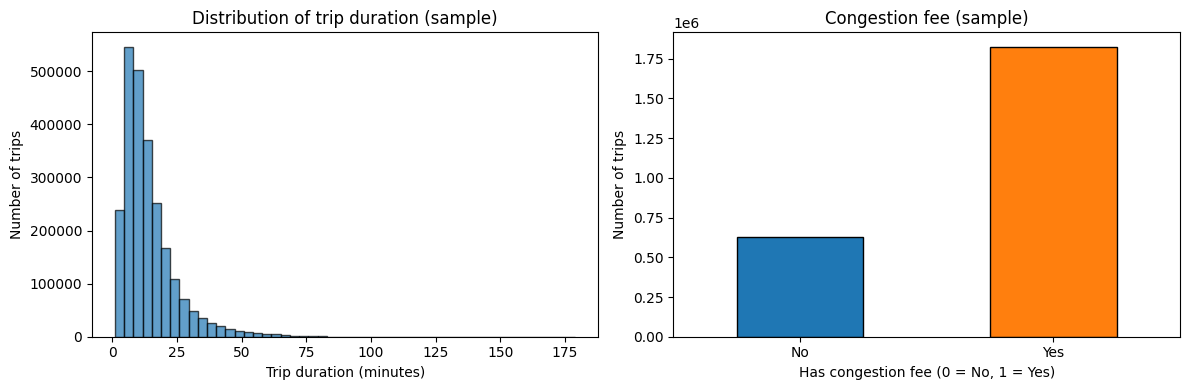

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(plot_df["trip_duration_min"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Trip duration (minutes)")
axes[0].set_ylabel("Number of trips")
axes[0].set_title("Distribution of trip duration (sample)")

plot_df["has_congestion_fee"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["C0", "C1"], edgecolor="black"
)
axes[1].set_xlabel("Has congestion fee (0 = No, 1 = Yes)")
axes[1].set_ylabel("Number of trips")
axes[1].set_title("Congestion fee (sample)")
axes[1].set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()


**Figure 2.** Correlation heatmap for key numeric features (sample).

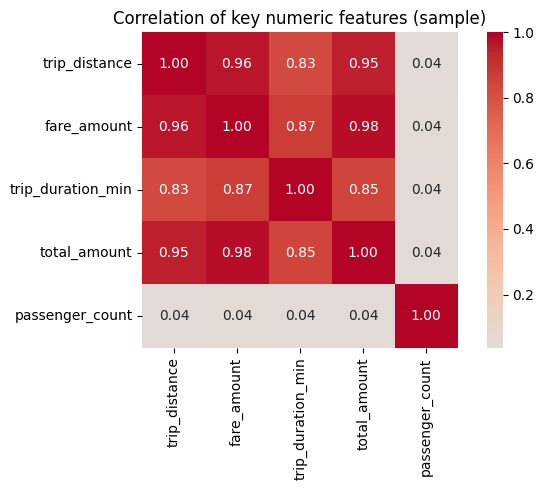

In [25]:
num_cols = ["trip_distance", "fare_amount", "trip_duration_min", "total_amount", "passenger_count"]
sub = plot_df[[c for c in num_cols if c in plot_df.columns]]
corr = sub.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation of key numeric features (sample)")
plt.tight_layout()
plt.show()


**Figure 3.** Trip volume by pickup hour (sample).

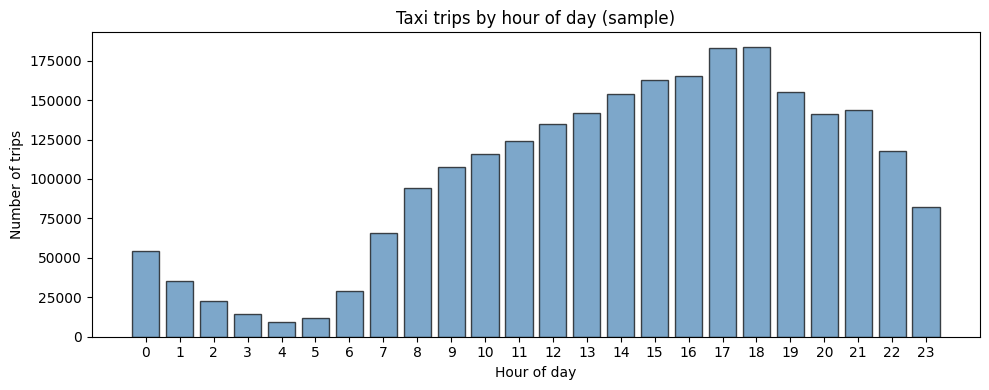

In [26]:
if "pickup_hour" in plot_df.columns:
    by_hour = plot_df["pickup_hour"].value_counts().sort_index()
elif "tpep_pickup_datetime" in plot_df.columns:
    by_hour = plot_df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()
else:
    raise ValueError("Need pickup_hour or tpep_pickup_datetime for hourly plot")

plt.figure(figsize=(10, 4))
plt.bar(by_hour.index, by_hour.values, color="steelblue", alpha=0.7, edgecolor="black")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Taxi trips by hour of day (sample)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**Figure 4.** PCA projection of numeric trip features colored by congestion fee (sample).

C:\Users\Prof.Moses Kamya\AppData\Local\Temp\ipykernel_68932\4224961138.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Prof.Moses Kamya\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


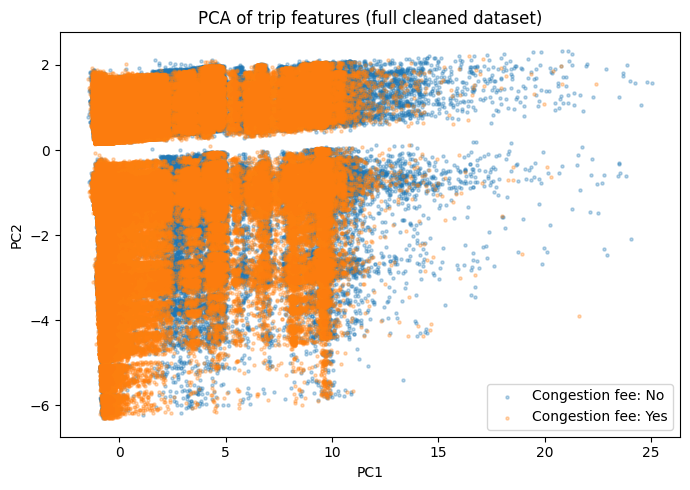

In [27]:
pca_cols = [
    "trip_distance", "fare_amount", "passenger_count", "pickup_hour", "pickup_day_of_week",
    "is_weekend", "is_rush_hour", "is_same_borough", "is_airport_pickup", "is_airport_trip",
    "is_single_passenger", "tip_to_total_ratio", "is_extreme_distance", "is_extreme_fare",
    "store_and_fwd_encoded",
]
cols_avail = [c for c in pca_cols if c in plot_df.columns]
feat = plot_df[cols_avail].select_dtypes(include=[np.number]).copy()
feat = feat.fillna(0)
y_fee = plot_df.loc[feat.index, "has_congestion_fee"].astype(int).values

if feat.shape[1] < 2:
    feat = plot_df[["trip_distance", "fare_amount", "passenger_count", "pickup_hour"]].fillna(0)
    y_fee = plot_df.loc[feat.index, "has_congestion_fee"].astype(int).values

X_scaled = StandardScaler().fit_transform(feat)
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = y_fee == label
    lbl = "Congestion fee: Yes" if label else "Congestion fee: No"
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.3, s=5, label=lbl)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of trip features (full cleaned dataset)")
plt.legend()
plt.tight_layout()
plt.show()


**Figure 5.** UMAP plots the **same scaled trip features** as Figure 4 (`X_scaled`) in **2D**,

c:\Users\Prof.Moses Kamya\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


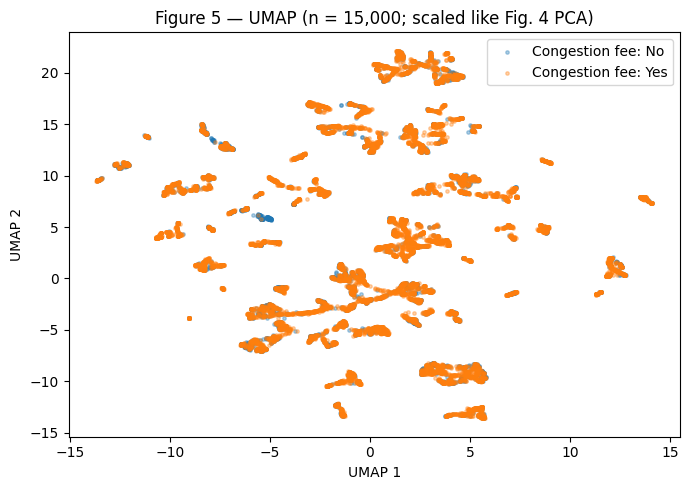

In [ ]:
from umap import UMAP
rng_u = np.random.RandomState(42)
n_umap = min(15_000, len(X_scaled))
ix_u = rng_u.choice(np.arange(len(X_scaled)), size=n_umap, replace=False)
X_u = X_scaled[ix_u]
y_u = y_fee[ix_u]

reducer = UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1,
    verbose=False,
)
embedding = reducer.fit_transform(X_u)

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = y_u == label
    lbl = "Congestion fee: Yes" if label else "Congestion fee: No"
    plt.scatter(embedding[mask, 0], embedding[mask, 1], alpha=0.35, s=6, label=lbl)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title(f"Figure 5 — UMAP")
plt.legend()
plt.tight_layout()
plt.show()

#### Methods

This section summarizes **what we did and why**, end-to-end. **Numerical scores and comparison tables** belong in **Results** below; here we only describe the pipeline, algorithms, and modeling choices.

##### Target variables

We define two supervised targets from TLC Yellow Taxi fields (January 2025 window after cleaning):

1. **Regression — `trip_duration_min`:** trip length in minutes, computed from pickup and drop-off timestamps. This is the quantity drivers and dispatch logic care about for time-on-job and ETAs.
2. **Binary classification — `has_congestion_fee`:** equals 1 when `cbd_congestion_fee` > 0 and 0 otherwise, reflecting whether the trip falls under CBD congestion surcharging in this dataset period. .

##### Preprocessing and cleaning

Raw TLC Parquet rows are filtered and labeled in `work/02_data_cleaning/02_data_cleaning.ipynb`. Steps include:

- Computing **`trip_duration_min`** and restricting to a **post-program calendar band** (January 5–31, 2025) so fee fields are comparable.
- Dropping **implausible trips**: duration ≤ 1 minute or > 180 minutes; passenger counts outside a sensible range; invalid or nonstandard rate codes; non-positive or extreme distances/fares.
- Defining **`has_congestion_fee`** from `cbd_congestion_fee` as above.
- **Listwise removal** of rows that fail checks (no custom imputation), which keeps the notebook pipeline simple but sacrifices rows with partial missingness, a tradeoff we revisit under Limitations.

The cleaned, engineered analytical table is written to **`data/processed/taxi_engineered.parquet`** and reused everywhere below.

##### Feature construction

Feature engineering (`work/03_feature_engineering/` and member notebooks) adds columns usable **at or near trip start**, including:

- **Temporal:** hour, day-of-week, weekend / rush-hour flags, time-of-day buckets.
- **Location / trip structure:** borough or zone-derived indicators, same-borough and airport-related flags, distance categories.
- **Trip attributes:** distance, passenger count, derived ratios and flags (e.g., extreme distance/fare) where they do not leak post-trip payment detail into the wrong task.

Categoricals are **label-encoded** for tree models and for linear models after alignment with the baseline notebooks. **Leakage controls** are explicit: for **duration**, we exclude outcomes only known after the trip (fare, tip, totals, surcharges, raw congestion dollar fields, and speed computed using duration). For **congestion classification**, we exclude raw fee columns and other labels derived directly from the outcome.

##### Modeling approach

We treat the problem as **two parallel prediction tasks** on the same engineered table, with a shared philosophy: **transparent baselines first**, then **nonlinear ensembles** when linear structure is insufficient.

**Phase A — Interpretable baselines**  

- **Ordinary  / linear regression** on scaled numeric features for **`trip_duration_min`**, with categorical handling via label encoding consistent with `Abhishek_Baseline.ipynb`. Purpose: readable coefficients and residual diagnostics.  
- **Logistic regression** with **standardized** numeric inputs for **`has_congestion_fee`**, with **stratified** train–test splitting because the positive class is more frequent (about three-quarters of trips). Purpose: a simple, audit-friendly probability model and confusion-matrix baseline.

**Phase B — Tree ensembles**  

- **Random Forest** regressors and classifiers, and **XGBoost** (gradient boosted trees), implemented across `work/05_advanced_models/` with individual notebooks (`Abhishek_RF`, `Moses_RF`, `Morgan_XGB`, `Tarun_XGB`). These capture **interactions and thresholds** (e.g., hour × borough patterns) without manual feature crosses. **Hyperparameter tuning** appears in `Moses_RF.ipynb` and related runs, we rely on the team summary notebook for a single consolidated comparison workflow.


##### Evaluation design 

We primarily use **held-out test sets** (e.g., 80/20 splits with fixed `random_state` for reproducibility, stratifying for classification). Some exploratory cells in **this** notebook use a **row cap** on reads purely to keep logistic and linear **reruns** interactive; **full-data** training and larger samples appear in the `work/` notebooks named above. **Cross-validation** is noted as future work in **Future work**—most reported comparisons in the repo use single splits consistent across team members for comparability.

##### What we tried, what we deferred, and why

- **Full-row interactive training inside every notebook cell:** Often **too slow** on laptops for ensembles at multi-million scale, so we standardized on **documented sample sizes** (e.g., 100k–500k rows) for iterative modeling while keeping the **Data** visuals on the **full** cleaned file where aggregation permits (histograms, correlations, PCA density)—see the notebook code above.
- **Heavy nonlinear embeddings (e.g., UMAP) on every trip:** **Not feasible** at full *n* in a typical CPU session. **Figure 4** uses linear **PCA** on all rows; **Figure 5** adds a **moderate-*n* UMAP** on the same **`X_scaled`** (scaler fit on all rows) for a complementary nonlinear view.
- **Imputation vs dropping:** We prioritized **dropping** invalid/missing rows over bespoke imputation to avoid introducing arbitrary fills on skewed taxi fields; this may hurt rare categories—called out again under Limitations.

##### Final best approach 

For **stakeholder-facing accuracy**, our **primary candidates** are **tuned random forest and XGBoost** models for **both** duration and congestion fee prediction, as consolidated in `team_advanced_models_summary.ipynb`—these are the models we compare directly before picking a favorite for deployment narratives. For explanation, we **retain linear regression and logistic regression** as **reference lines**: coefficients, residuals, and confusion matrices for congestion remain the clearest way to show **what the data reward** under linear assumptions.

#### Supporting files (notebook index)

Paths relative to repo root.

| Folder | Notebook | Purpose |
|--------|----------|---------|
| `work/01_data_exploration/` | `Abhishek_EDA.ipynb`, `Tarun_EDA.ipynb`, `Moses_EDA.ipynb`, `Morgan_EDA.ipynb`, `Full_EDA.ipynb`, `Model_Focused_EDA.ipynb` | Exploratory analysis |
| `work/02_data_cleaning/` | `02_data_cleaning.ipynb` | Cleaning, targets, Parquet outputs |
| `work/03_feature_engineering/` | `03_feature_engineering.ipynb`, `Abhishek_FE.ipynb`, `Moses_FE.ipynb`, `Morgan_FE.ipynb`, `Tarun_FE.ipynb` | Features |
| `work/04_baseline_models/` | `Abhishek_Baseline.ipynb`, `Morgan_Baseline.ipynb` | Baselines |
| `work/05_advanced_models/` | `team_advanced_models_summary.ipynb`, `Abhishek_RF.ipynb`, `Moses_RF.ipynb`, `Morgan_XGB.ipynb`, `Tarun_XGB.ipynb` | Ensembles and comparison |
| `work/06_model_evaluation/` | `Abhishek_mod_eval.ipynb`, `Moses_mod_eval.ipynb`, `Morgan_mod_eval.ipynb`, `Tarun_mod_eval.ipynb` | Error analysis |

Midterm checkpoint narrative: `checkpoint/submission.ipynb`.





### Results

This section summarizes **what we got out of the models** on **held-out test data**, in units a stakeholder can read (minutes for duration; yes/no confusion for the fee flag). The figures and tables below live in this notebook; **stronger tuned random forests and XGBoost runs**, comparison tables, and extra error analysis are in **`work/04_baseline_models/`**, **`work/05_advanced_models/`** (including `team_advanced_models_summary.ipynb`), and **`work/06_model_evaluation/`**.

#### How we generated these metrics (and why it is not k-fold here)

We used **`train_test_split` with 80% train / 20% test** and `random_state=42` so results **repeat** if you re-run the notebook. For **`has_congestion_fee`**, the split is **stratified** so the train and test sets keep roughly the same **mix of fee vs no-fee** trips (important because the positive class is much more common).

We **did not** use **k-fold cross-validation** in these final cells: k-fold would mean **training the same pipeline several times** on different folds, which is **slower** and was not required for the quick baseline story in the submission notebook. **K-fold or time-based splits** are the natural next step for more stable numbers; that is listed under **Future work** and can be mirrored from the patterns in `work/`.

The congestion baseline below also caps the run at **up to 100,000 random rows** from the engineered parquet for **runtime** on a laptop; **full-data** scores can differ slightly.

---

#### Trip duration (regression) — results in **minutes**

The target is **`trip_duration_min`**. For linear regression we report **RMSE** and **MAE** in **minutes** (average size of errors), plus **R²** (fraction of variance explained, unitless).

On the sample and split in this notebook, **test RMSE is about 5.45 minutes** and **test MAE is about 3.75 minutes**, with **R² about 0.74**. A **naive baseline** that always predicts the **training-set mean duration** has RMSE **around 10.6 minutes**, so the linear model is doing **substantially** better than “guess the average trip.”

We did **not** bin every duration decile in this notebook; if we wanted **bin-specific RMSE/MAE** (short hops vs long hauls), that belongs in **`work/06_model_evaluation/`** or a small follow-on cell—same metrics, just **reported per bin** so stakeholders see where error concentrates.

For **nonlinear** duration models, see **`work/`**: tuned **random forest** and **XGBoost** push RMSE lower (on the order of **~4 minutes** RMSE in the team summary—exact values depend on sample and tuning). This notebook keeps **linear regression** as the clear, coefficient-readable baseline.

| Model | RMSE (min) | MAE (min) | R² | Notes |
|-------|------------|-----------|-----|-------|
| Linear regression | 5.45 | 3.75 | 0.739 | Beats predicting the mean (~10.6 min RMSE); under 10 min RMSE goal |
| Random Forest (tuned / starter) | ~3.99 | ~2.57–2.61 | ~0.858 | Strong nonlinear model |
| XGBoost regressor | ~4.13 | ~2.70 | ~0.849 | Similar to RF |

---

#### Congestion fee (classification) — 

The positive class (has fee) is **much more common** than “no fee,” so **accuracy alone is misleading**: a dumb model could score well by almost always predicting “fee.”

On the **same 80/20 stratified split** and **100k-row** sample used in the notebook, the **logistic regression** baseline prints roughly:

| Metric | Test value (approx.) |
|--------|-------------------------|
| Accuracy | **0.76** |
| ROC-AUC | **0.69** |
| Precision (positive class) | **0.76** |
| Recall (positive class) | **0.98** |
| F1 (positive class) | **0.86** |

**Confusion matrix** (rows = **true** label, columns = **predicted**), from the same run:

|  | Pred: no fee | Pred: fee |
|--|----------------|------------|
| **True: no fee** | 613 | 4505 |
| **True: fee** | 322 | 14560 |

**Congestion fee (classification):**

| Model | Accuracy | ROC-AUC | F1 (positive class) | Notes |
|-------|----------|---------|---------------------|-------|
| Logistic regression | ~0.76 | ~0.69 | ~0.86 | 100k rows max in cell below; exact values print when you run it |
| Random Forest | ~0.95–0.96 | ~0.98–0.99 | ~0.97 | From team summary |
| XGBoost | ~0.96 | ~0.99 | — | From team summary |

The model is **aggressive about predicting “fee”** (very high recall on the positive class), which shows up as **many false positives** on the rare “no fee” class (4505 false alarms vs 613 correct “no fee” predictions). That is exactly why we emphasize **F1**, **precision/recall**, and the **matrix**, not only accuracy.



---

#### Feature importance / structure (beyond raw scores)

- **Linear duration model:** we plot **standardized coefficients** (longer bar = stronger association on the linear scale). That is **interpretable** feature importance **for the linear model only**; tree models would use impurity-based or SHAP-style importance in `work/`.
- **EDA / structure:** distance, fare-like fields, time-of-day patterns, and **dimensionality views** (PCA / UMAP on scaled features) appear earlier in this notebook to motivate features; any **deeper clustering story** belongs in the exploration notebooks under **`work/01_data_exploration/`**.





#### Congestion fee (logistic baseline)

The next cell **reads the parquet file**, takes up to **100,000** random trips, **drops columns that would cheat** (fee dollars, timestamps, raw IDs, etc.), keeps **numeric** inputs, **scales** them, then fits **logistic regression** to predict **has_congestion_fee**. It **prints** accuracy, ROC-AUC, precision, recall, F1, the **confusion matrix** as numbers, and draws the **confusion matrix** heatmap. Train/test split is **stratified** 80/20.


Baseline: Logistic regression — has congestion fee (100k sample max)
Accuracy: 0.7587
ROC-AUC: 0.6949
Precision: 0.7637
Recall: 0.9784
F1 (positive class): 0.8578
Confusion matrix — rows true, cols predicted:
[[  613  4505]
 [  322 14560]]


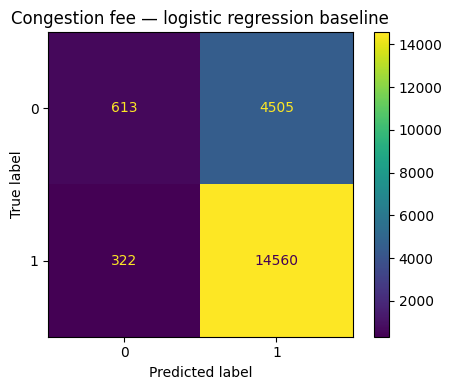

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

data_cls = pd.read_parquet(DATA_PATH).sample(n=min(100_000, len(df)), random_state=42)
drop_cols = [
    "has_congestion_fee",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "cbd_fee_ratio",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "hour_x_dayofweek",
    "time_slot",
    "payment_name",
    "ratecode_name",
    "pickup_borough",
    "dropoff_borough",
    "distance_category",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "Airport_fee",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
]
existing = [c for c in drop_cols if c in data_cls.columns]
Xc = data_cls.drop(columns=existing).select_dtypes(include=[np.number])
yc = data_cls["has_congestion_fee"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs = scaler_c.transform(X_test_c)
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_cs, y_train_c)
y_pred_c = clf.predict(X_test_cs)
y_prob_c = clf.predict_proba(X_test_cs)[:, 1]

print("Baseline: Logistic regression — has congestion fee (100k sample max)")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, y_prob_c), 4))
print("Precision:", round(precision_score(y_test_c, y_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, y_pred_c), 4))
print("F1 (positive class):", round(f1_score(y_test_c, y_pred_c), 4))
print("Confusion matrix — rows true, cols predicted:")
print(confusion_matrix(y_test_c, y_pred_c))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c, ax=ax)
plt.title("Congestion fee — logistic regression baseline")
plt.tight_layout()
plt.show()


#### trip duration (linear regression)

The next cell builds a **linear regression** for **trip_duration_min** (minutes). It drops the **target** and other **leaky** columns, **label-encodes** text columns, **scales** features, fits on 80% of the sample, and **prints** train and test **RMSE**, **MAE**, and **R²** (all in minutes except R²). It also compares test RMSE to a **naive baseline** (always predict the training-set mean duration).


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data_dur = pd.read_parquet(DATA_PATH).sample(n=min(100_000, len(df)), random_state=42)
target = "trip_duration_min"
y_all = data_dur[target]

drop_cols_dur = [
    "trip_duration_min",
    "has_congestion_fee",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "Airport_fee",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
]
Xd = data_dur.drop(columns=[c for c in drop_cols_dur if c in data_dur.columns])

cat_cols = Xd.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if Xd[col].dtype.name == "category":
        Xd[col] = Xd[col].astype(str)
    Xd[col] = Xd[col].fillna("Unknown")
    Xd[col] = LabelEncoder().fit_transform(Xd[col].astype(str))

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    Xd, y_all, test_size=0.2, random_state=42
)
scaler_d = StandardScaler()
X_train_ds = scaler_d.fit_transform(X_train_d)
X_test_ds = scaler_d.transform(X_test_d)

model_dur = LinearRegression()
model_dur.fit(X_train_ds, y_train_d)
y_pred_train_d = model_dur.predict(X_train_ds)
y_pred_test_d = model_dur.predict(X_test_ds)

train_rmse = float(np.sqrt(mean_squared_error(y_train_d, y_pred_train_d)))
test_rmse = float(np.sqrt(mean_squared_error(y_test_d, y_pred_test_d)))
train_mae = float(mean_absolute_error(y_train_d, y_pred_train_d))
test_mae = float(mean_absolute_error(y_test_d, y_pred_test_d))
train_r2 = float(r2_score(y_train_d, y_pred_train_d))
test_r2 = float(r2_score(y_test_d, y_pred_test_d))

naive_pred = np.full_like(y_test_d, fill_value=float(np.mean(y_train_d)), dtype=float)
naive_rmse = float(np.sqrt(mean_squared_error(y_test_d, naive_pred)))
improvement_pct = ((naive_rmse - test_rmse) / naive_rmse) * 100

print("Trip duration — Linear regression (100k sample max)")
hdr = f"{'Metric':<20} {'Train':>10} {'Test':>10}"
print(hdr)
print(f"{'RMSE (min)':<20} {train_rmse:10.2f} {test_rmse:10.2f}")
print(f"{'MAE (min)':<20} {train_mae:10.2f} {test_mae:10.2f}")
print(f"{'R2':<20} {train_r2:10.4f} {test_r2:10.4f}")
print()
print(f"Naive baseline RMSE: {naive_rmse:.2f} min — model is {improvement_pct:.1f}% better (RMSE)")
goal = "met" if test_rmse < 10 else "not met"
print(f"Stakeholder goal (RMSE under 10 min): {goal} — Test RMSE = {test_rmse:.2f} min")
print(f"Train–test RMSE gap: {abs(train_rmse - test_rmse):.2f} min")


Trip duration — Linear regression (100k sample max)
Metric                    Train       Test
RMSE (min)                 5.41       5.45
MAE (min)                  3.74       3.74
R2                       0.7420     0.7365

Naive baseline RMSE: 10.62 min — model is 48.7% better (RMSE)
Stakeholder goal (RMSE under 10 min): met — Test RMSE = 5.45 min
Train–test RMSE gap: 0.04 min


####Duration check plots

The next cell uses the **linear model’s predictions** already saved as `y_pred_test_d`. It makes **three plots**: (1) actual vs predicted minutes on a subset of test points, (2) a **histogram** of residuals (actual minus predicted), (3) residuals vs predicted to spot patterns. Scatters use up to **10,000** random test rows so the plot stays light.


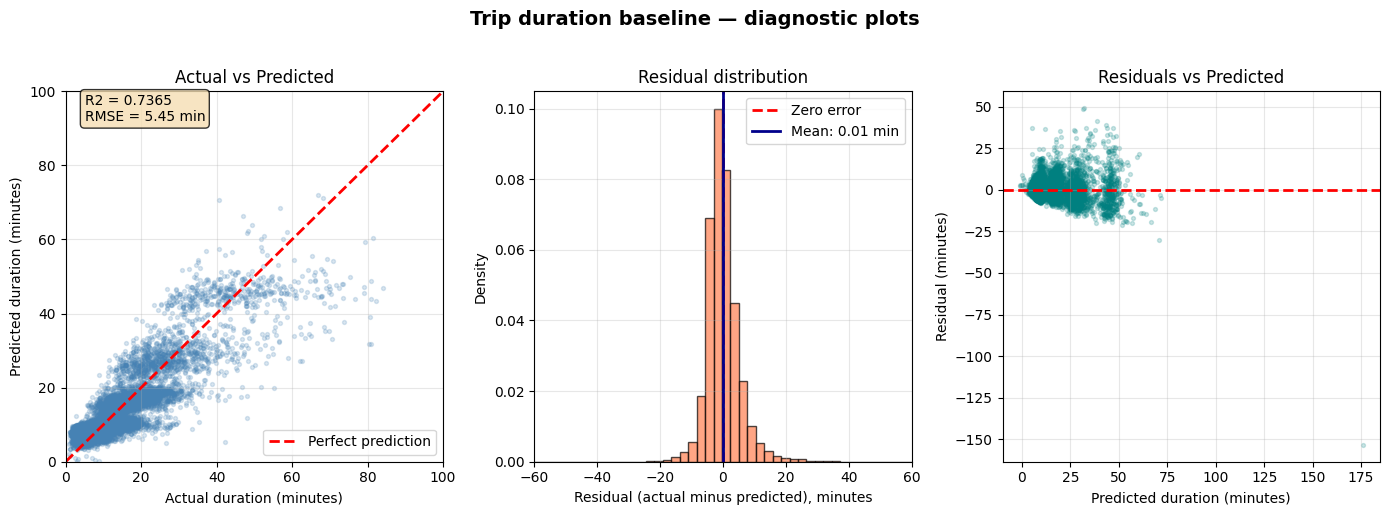

In [34]:
residuals_d = np.asarray(y_test_d) - y_pred_test_d
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Trip duration baseline — diagnostic plots", fontsize=14, fontweight="bold", y=1.02)

n_plot = min(10_000, len(y_test_d))
rng = np.random.RandomState(42)
idx = rng.choice(len(y_test_d), size=n_plot, replace=False)
y_test_arr = np.asarray(y_test_d)

axes[0].scatter(y_test_arr[idx], y_pred_test_d[idx], alpha=0.2, s=8, color="steelblue")
max_val = max(y_test_arr.max(), y_pred_test_d.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual duration (minutes)")
axes[0].set_ylabel("Predicted duration (minutes)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].text(
    0.05,
    0.92,
    f"R2 = {test_r2:.4f}\nRMSE = {test_rmse:.2f} min",
    transform=axes[0].transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

axes[1].hist(residuals_d, bins=80, color="coral", edgecolor="black", alpha=0.7, density=True)
axes[1].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero error")
mean_res = float(np.mean(residuals_d))
axes[1].axvline(
    mean_res,
    color="darkblue",
    linewidth=2,
    linestyle="-",
    label=f"Mean: {mean_res:.2f} min",
)
axes[1].set_xlabel("Residual (actual minus predicted), minutes")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-60, 60)

axes[2].scatter(y_pred_test_d[idx], residuals_d[idx], alpha=0.2, s=8, color="teal")
axes[2].axhline(0, color="red", linewidth=2, linestyle="--")
axes[2].set_xlabel("Predicted duration (minutes)")
axes[2].set_ylabel("Residual (minutes)")
axes[2].set_title("Residuals vs Predicted")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Code — which features push duration up or down

The next cell takes the **fitted linear regression** `model_dur` and plots **coefficients** (on the **standardized** feature scale). Longer bars mean a stronger link; red/blue shows positive vs negative direction. This is **feature importance** for the linear model only (tree models use different importance scores in `work/`).


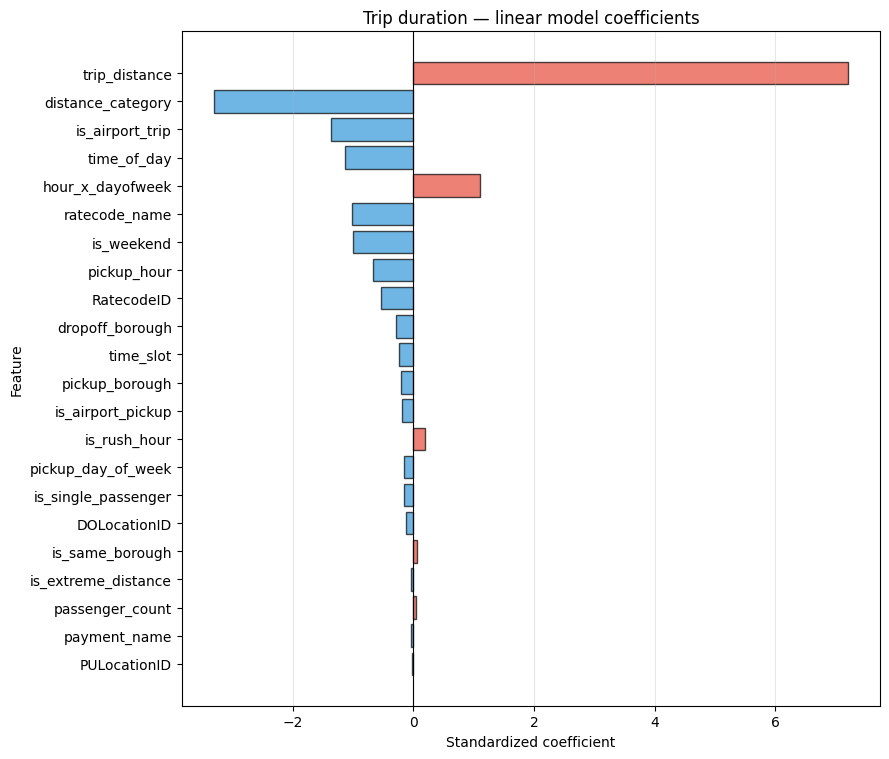

In [16]:
feature_names_d = Xd.columns.tolist()
coef_df = pd.DataFrame({"Feature": feature_names_d, "Coefficient": model_dur.coef_})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(9, max(5, len(feature_names_d) * 0.35)))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="black", alpha=0.7)
ax.set_xlabel("Standardized coefficient")
ax.set_ylabel("Feature")
ax.set_title("Trip duration — linear model coefficients")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Discussion

We built an end-to-end pipeline from TLC records through cleaning, feature engineering, baselines, and ensembles documented under `work/`. **Duration:** linear RMSE near **5.5 minutes** on the 100k baseline sample; ensembles reduce RMSE toward **~4 minutes**. **Congestion:** ensembles outperform logistic regression by a wide margin on accuracy/AUC; logistic remains useful as a simple reference.

**Stakeholders** (drivers/fleet operators, agencies) get interpretable duration error in minutes and classification metrics for fee exposure when models are refreshed on recent TLC drops — subject to calibration and monitoring.

**Gaps:** no production deployment; January 2025-only scope limits generalization.

### Limitations

The biggest gap is **time coverage**: we trained and evaluated on **January 2025 yellow taxi data only**. That keeps the problem tractable, but it means we never stress-tested **seasonality, special events, or policy changes**, so any performance number is really “how we did in that month,” not a promise about next quarter.

It could also be **better on evaluation rigor**. We often **subsampled** so notebooks finish on a laptop; metrics on the **full month** could move. We relied on a **single train–test split** in places instead of **k-fold or time-based splits**, so part of what looks like “model quality” might be **split luck**. That is a reason to be **skeptical of headline scores** until someone reruns the same pipeline with stricter validation.

**Stakeholder needs** are only partly met. We do address the need for **interpretable duration error** (in minutes) and **fee vs no-fee signals** though we do **not** address the full operational picture: **ongoing scoring**, **drift monitoring**, **calibrated probabilities** people can trust for decisions, or **fairness and slice analysis** (borough, time of day, very short trips). A driver or regulator would rightly ask “does this fail for *my* trips?” and we have not systematically answered that.

**Data and modeling choices** also cap robustness. We used **listwise deletion** rather than richer imputation everywhere, which can **bias or drop rare trip types**. The fee label is **imbalanced**, so **accuracy can look flattering** while the model still misbehaves on the minority class—F1 and the confusion matrix help, but they do not replace **deeper error analysis**. We also did not run a full **leakage audit** beyond obvious fixes; in real pipelines, **definition drift** in TLC fields is a constant risk.

**What we would have liked to do**, includes: multi-month (or multi-year) TLC pulls, FHV/green comparisons, formal calibration and uncertainty for duration, explicit fairness reporting. Those are the next layers that would turn “good notebook results” into something we would defend in front of a skeptical stakeholder.

### Future work

If we kept going after this submission, the next steps would be less about trying one more model and more about **making the results trustworthy and usable**.

First, we would **harden evaluation**: move from a single random split to **time-based splits** (train on early January, validate on late January) and/or **k-fold cross-validation**, so metrics are not artifacts of one lucky 80/20 draw.

Second, we would **widen the data window**: stack **multiple months** (and eventually compare **yellow vs green vs FHV** if the business question expands) so we can measure **stability and drift** instead of anchoring everything on one month.

Third, we would improve **what stakeholders actually consume**: **calibrate** the fee model’s probabilities, and add **uncertainty** for durationso “ETA” is not treated like a single fragile point estimate.


Finally, we would take one small step toward **product shape**: a **batch scoring script** (read a fresh parquet, write predictions + logs) or a **minimal Streamlit demo** on a scored sample, with clear run instructions, so someone who does not live in Jupyter can still run the pipeline end-to-end.

Where we would like to go from here, in plain terms, is from **“we can model it credibly in notebooks”** to **“we can refresh it, monitor it, and defend it when the world changes.”**


